# Self Organizing Maps --Som


In [1]:
import matplotlib.pyplot as plt
from minisom import MiniSom
from keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape((x_train.shape[0], -1)) / 255.0


# Use a subset for faster training

x_train = x_train[:1000]  
y_train = y_train[:1000]




In [9]:
# minisom(som-width, som-height, input_len, sigma, learning_rate,neighborhood_function='triangle', activation_distance='euclidean',topology='rectangular')
# Initialize and train the SOM
som = MiniSom( 
              30, # Som-width
              30, # Som-height 
              x_train.shape[1], # input_len
              sigma=1.5,
              learning_rate=0.5,
              neighborhood_function='triangle',
              activation_distance='euclidean',
              topology='rectangular',
              sigma_decay_function='linear_decay_to_one',
              decay_function='linear_decay_to_zero',
              random_seed=349
)

som.pca_weights_init(x_train)

som.train( 
           x_train,
           1000,   # number of iterations
           verbose=True
)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 5.227754416149566


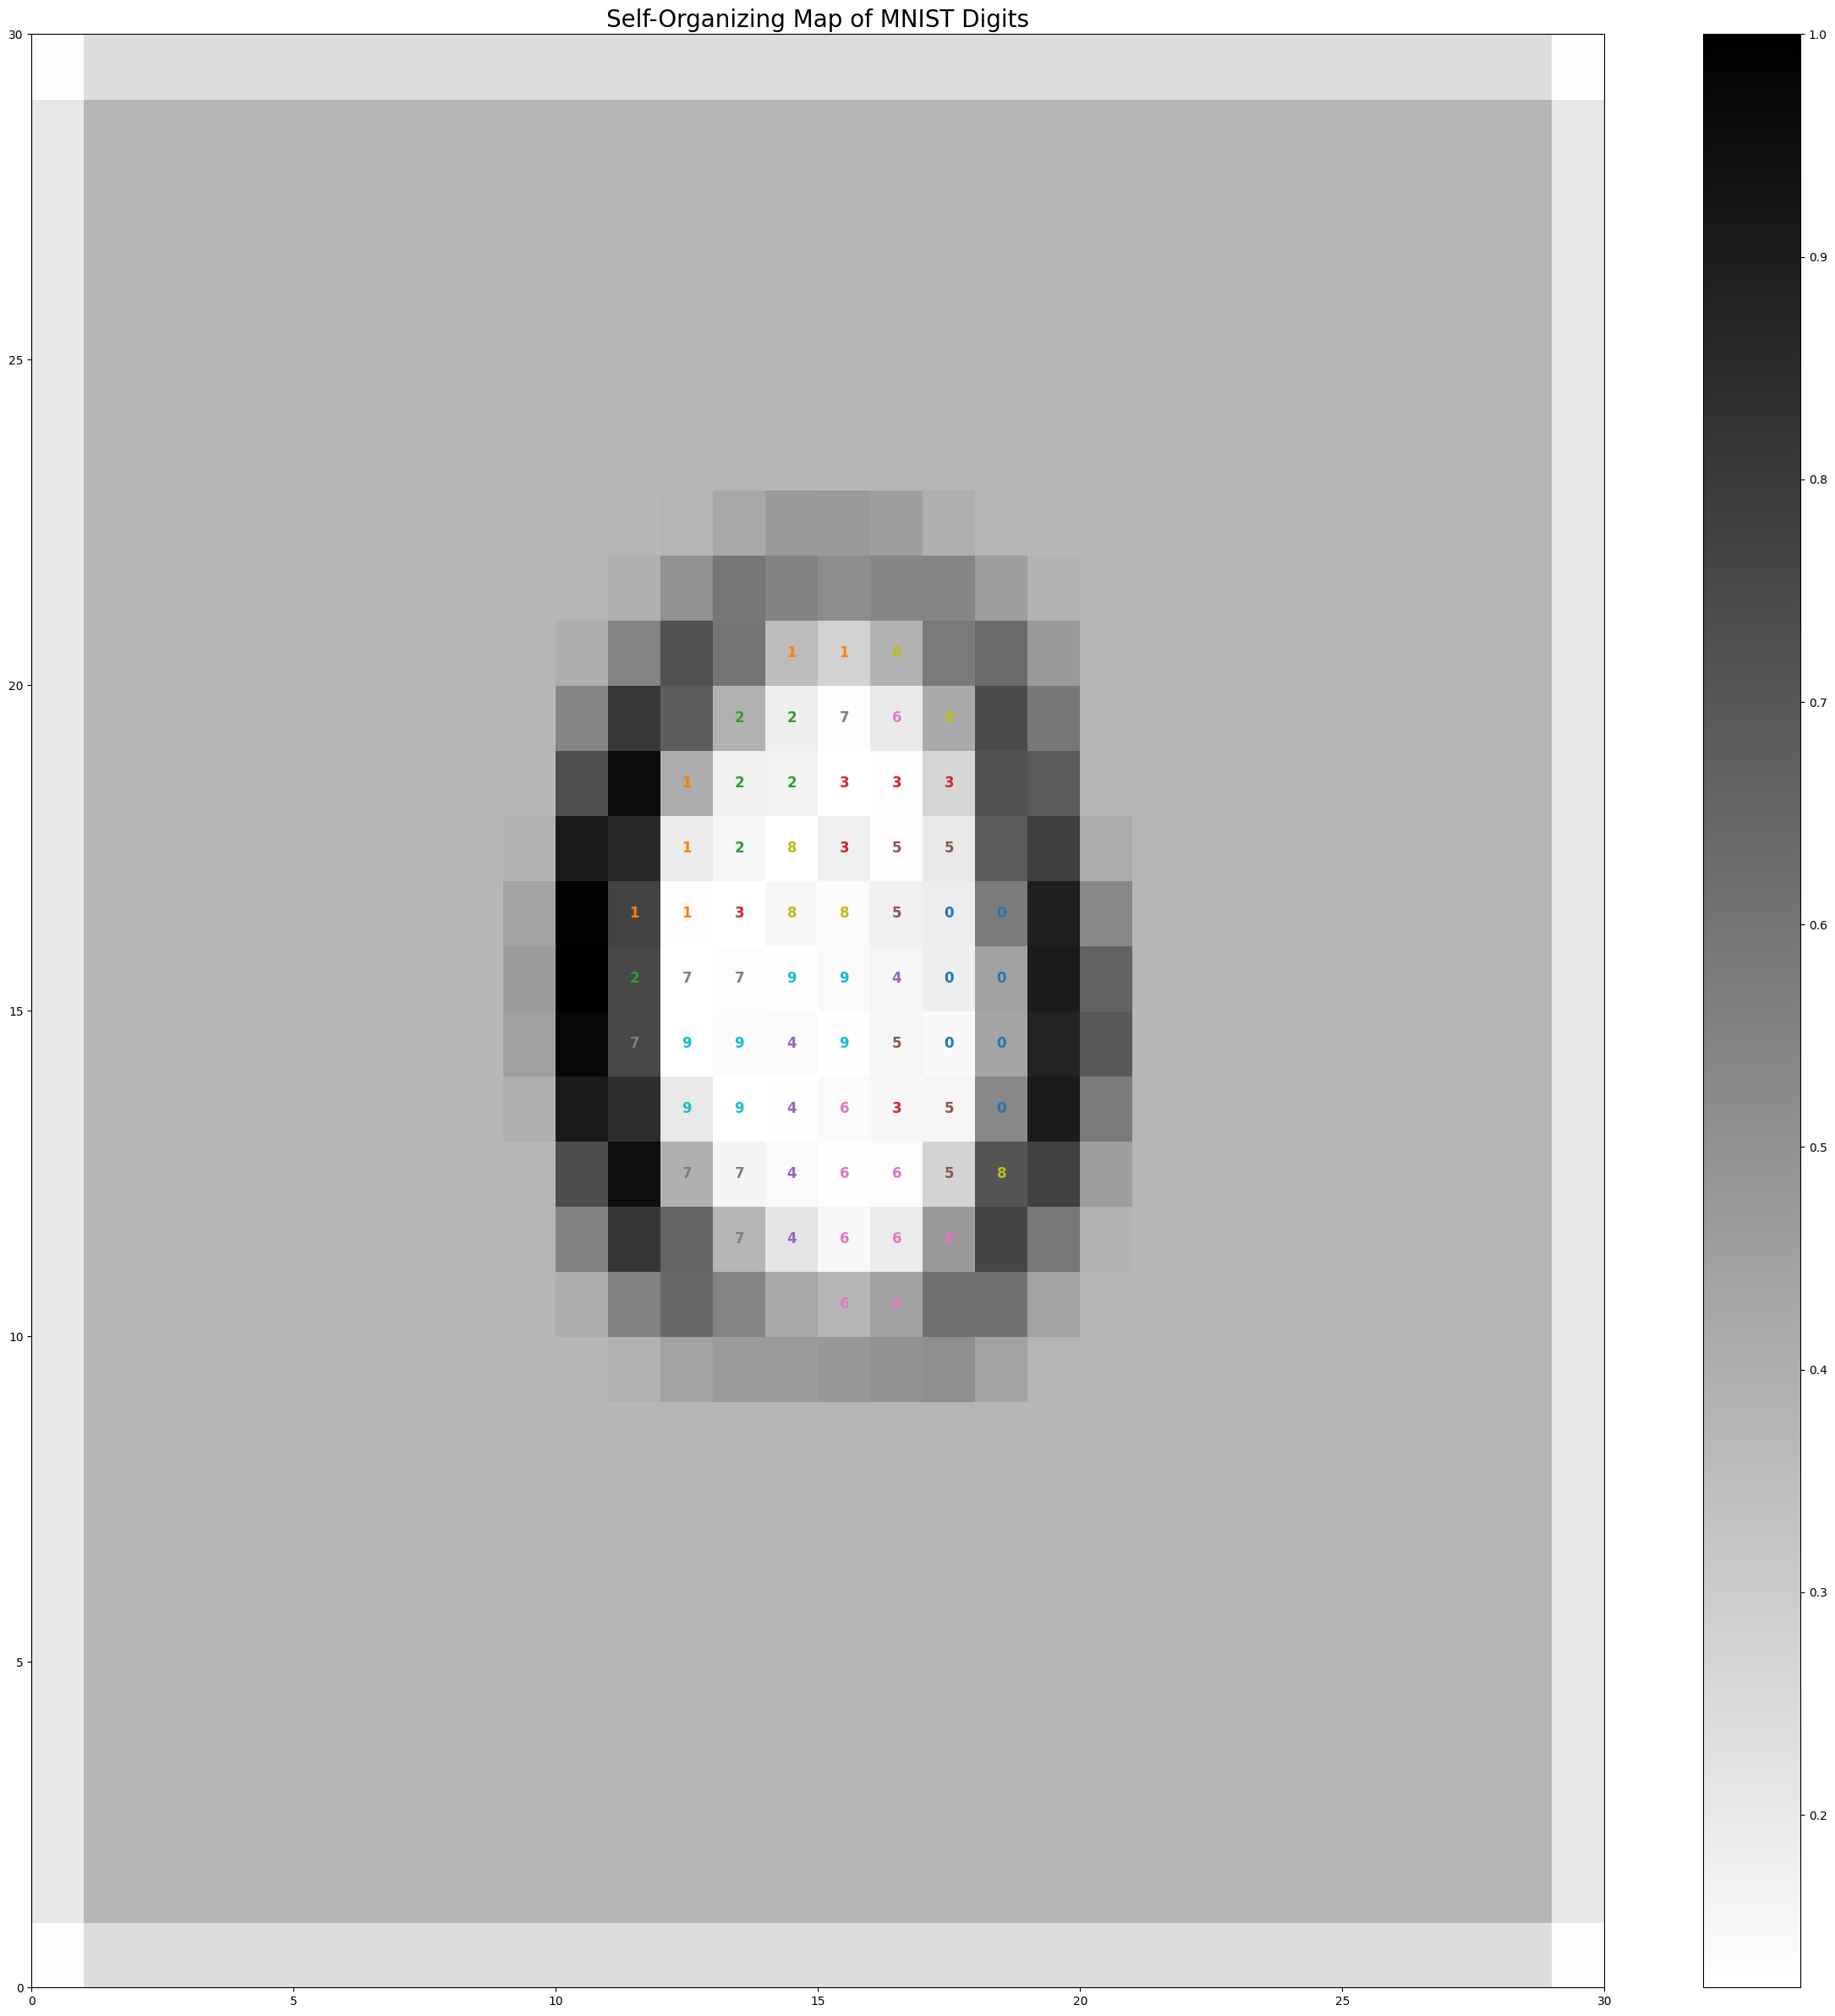

In [10]:
# Visualize the SOM
plt.figure(figsize=(30,30))
plt.pcolor(som.distance_map().T, cmap='gist_yarg')  # distance map as background
plt.colorbar()

Bmu_neuron_Count = {}
for i, x in enumerate(x_train):
    w = som.winner(x)
    if w not in Bmu_neuron_Count:
        Bmu_neuron_Count[w] = {}
    digit = y_train[i]
    Bmu_neuron_Count[w][digit] = Bmu_neuron_Count[w].get(digit, 0) + 1


# Plotting the digits on the map
for coord, digit_count in Bmu_neuron_Count.items():
   most_frequent_digit = max(digit_count, key=digit_count.get)
   plt.text(coord[0] + 0.5, coord[1] + 0.5, str(most_frequent_digit),
                color='C{}'.format(most_frequent_digit),
                fontdict={'weight': 'bold', 'size': 12},
                ha='center', # horizontal alignment
                va='center' # vertical alignment
  )
   

plt.title('Self-Organizing Map of MNIST Digits', fontsize=20)
plt.show()

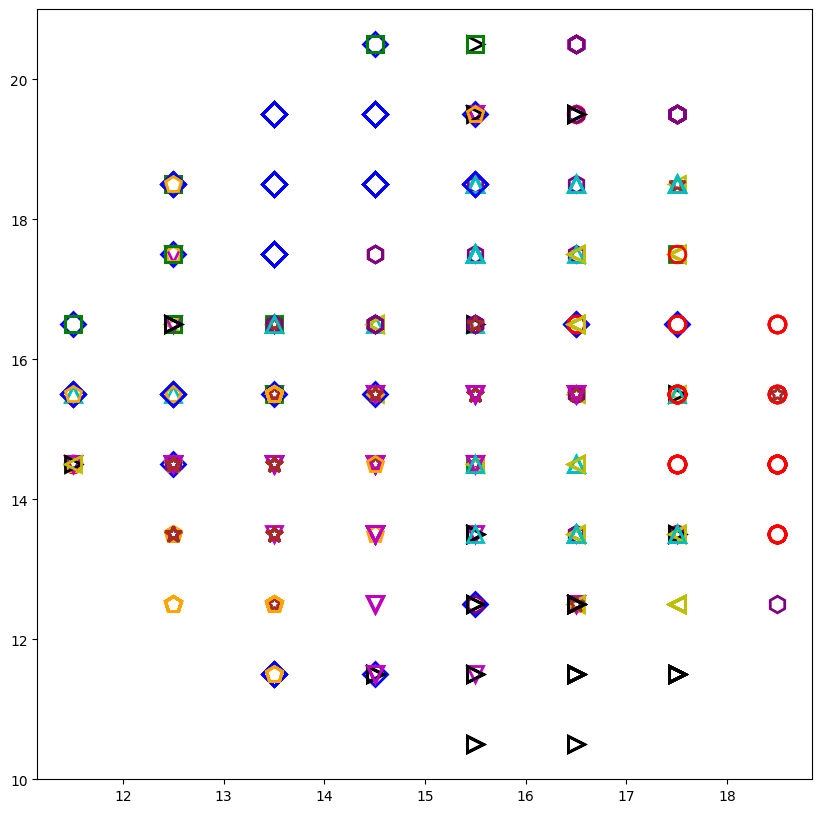

In [11]:
# ploting lattice

markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*']
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown']
plt.figure(figsize=(10,10))
for count , x in enumerate(x_train):
    w = som.winner(x)
    plt.plot(
        w[0] + 0.5,
             w[1] + 0.5,
             markers[y_train[count]],
             markerfacecolor='None',
             markeredgecolor=colors[y_train[count]],
             markersize=12,
             markeredgewidth=2
    )

plt.show()